#**Portfolio Allocation Using Python**

##**Data Collection and importing libraries.**


In [10]:
import requests
import pandas as pd
from datetime import date
from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import *


"""import yfinance as yf

def get_price_history(symbols: list[str], start_date: str, end_date: str) -> pd.DataFrame:

   ## Downloads historical stock prices from Yahoo Finance for multiple symbols
    ##and returns them in a single long-format DataFrame.


    all_dfs = []

    for symbol in symbols:
        print(f"Downloading data for {symbol}...")
        df = yf.download(symbol,
                         start=start_date,
                         end=end_date,
                         auto_adjust=True, # Auto-adjust for splits and dividends
                         progress=False)

        if not df.empty:
            # Keep only 'Close' (which is adjusted close due to auto_adjust=True)
            # and rename to 'close' to match later pivot operation
            df_filtered = df[['Close']].copy()
            df_filtered.columns = ['close']
            df_filtered['symbol'] = symbol
            df_filtered['date'] = df_filtered.index # Make 'Date' a column
            df_filtered.reset_index(drop=True, inplace=True) # Reset index to be default integer index
            all_dfs.append(df_filtered)
            print(df_filtered.head())
        else:
            print(f"No data downloaded for {symbol}.")

        print("-" * 60)

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame(columns=['date', 'symbol', 'close'])"""

'import yfinance as yf\n\ndef get_price_history(symbols: list[str], start_date: str, end_date: str) -> pd.DataFrame:\n\n   ## Downloads historical stock prices from Yahoo Finance for multiple symbols\n    ##and returns them in a single long-format DataFrame.\n\n\n    all_dfs = []\n\n    for symbol in symbols:\n        print(f"Downloading data for {symbol}...")\n        df = yf.download(symbol,\n                         start=start_date,\n                         end=end_date,\n                         auto_adjust=True, # Auto-adjust for splits and dividends\n                         progress=False)\n\n        if not df.empty:\n            # Keep only \'Close\' (which is adjusted close due to auto_adjust=True)\n            # and rename to \'close\' to match later pivot operation\n            df_filtered = df[[\'Close\']].copy()\n            df_filtered.columns = [\'close\']\n            df_filtered[\'symbol\'] = symbol\n            df_filtered[\'date\'] = df_filtered.index # Make \'Date

In [11]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sci_opt

from pprint import pprint
from sklearn.preprocessing import StandardScaler

# Set some display options for Pandas.
pd.set_option('display.max_colwidth',None) #changed -1 to none
pd.set_option('expand_frame_repr', False)

In [12]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sci_opt

from pprint import pprint
from sklearn.preprocessing import StandardScaler
from datetime import datetime # Ensure datetime is imported for direct use

"""# Set some display options for Pandas.
pd.set_option('display.max_colwidth',None)
pd.set_option('expand_frame_repr', False)

# Define the symbols
symbols = ['HDFCBANK.NS','TCS.NS' , 'ICICIBANK.NS' , 'SBIN.NS' , 'INFY.NS' ,
           'BHARTIARTL.NS' , 'RELIANCE.NS' , 'TATAMOTORS.NS' , 'M&M.NS' , 'HINDUNILVR.NS',
           'ITC.NS','SUNPHARMA.NS' , 'DRREDDY.NS' , 'LT.NS' , 'BAJFINANCE.NS','SBILIFE.NS',
           'ULTRACEMCO.NS','TITAN.NS','NTPC.NS','BEL.NS']   #20 Stocks from diverse industries

# At different points, we will need to generate metrics based on the number
# of symbols we have, so let's save some time and just calculate that now.
number_of_symbols = len(symbols)

# Ensure the 'data' directory exists
data_dir = pathlib.Path('data')
data_dir.mkdir(parents=True, exist_ok=True)
csv_file_path = data_dir / 'stock_data_1.csv'

# If we don't have data then grab it
if not csv_file_path.exists():

    # Call get_price_history, which now returns a DataFrame directly.
    price_data_frame = get_price_history(symbols=symbols ,start_date = '2022-05-20', end_date = '2026-06-30') #date has been changed to a fixed date because it is difficult to process yfinance libraries in streamlit.

    # Dump it to a CSV file.
    price_data_frame.to_csv(
        csv_file_path,
        index=False
    )
    print("Saved data to stock_data_1.csv")

else:

    # Load the data.
    price_data_frame: pd.DataFrame = pd.read_csv(csv_file_path)

# Print the head.
print(price_data_frame.head())"""  #some code has been commented out because we do not want to do function calls from yfinance again and again as that takes a lot of time during deployment.
                                    #originally , the dataset was obtained from yfinance itself.

'# Set some display options for Pandas.\npd.set_option(\'display.max_colwidth\',None)\npd.set_option(\'expand_frame_repr\', False)\n\n# Define the symbols\nsymbols = [\'HDFCBANK.NS\',\'TCS.NS\' , \'ICICIBANK.NS\' , \'SBIN.NS\' , \'INFY.NS\' ,\n           \'BHARTIARTL.NS\' , \'RELIANCE.NS\' , \'TATAMOTORS.NS\' , \'M&M.NS\' , \'HINDUNILVR.NS\',\n           \'ITC.NS\',\'SUNPHARMA.NS\' , \'DRREDDY.NS\' , \'LT.NS\' , \'BAJFINANCE.NS\',\'SBILIFE.NS\',\n           \'ULTRACEMCO.NS\',\'TITAN.NS\',\'NTPC.NS\',\'BEL.NS\']   #20 Stocks from diverse industries\n\n# At different points, we will need to generate metrics based on the number\n# of symbols we have, so let\'s save some time and just calculate that now.\nnumber_of_symbols = len(symbols)\n\n# Ensure the \'data\' directory exists\ndata_dir = pathlib.Path(\'data\')\ndata_dir.mkdir(parents=True, exist_ok=True)\ncsv_file_path = data_dir / \'stock_data_1.csv\'\n\n# If we don\'t have data then grab it\nif not csv_file_path.exists():\n\n    # Cal

In [13]:
price_data_frame = pd.read_csv('stock_data_1.csv')

####*It will be convenient for us to see the target variable(close price) at the end , so let us rearrange the columns of this dataframe.*

In [14]:
# don't need all columns so we will store only useful columns
price_data_frame = price_data_frame[['date', 'symbol', 'close']]

#arranging the data around date
price_data_frame = price_data_frame.pivot(
    index='date',
    columns='symbol',
    values='close'
)
price_data_frame

symbol,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,M&M.NS,NTPC.NS,RELIANCE.NS,SBILIFE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TITAN.NS,ULTRACEMCO.NS
date,,,,,,,,,,,,,,,,,,,
2022-05-20,562.623596,74.870781,663.969666,822.094116,625.257080,2145.845947,688.277344,1278.627808,225.764633,1530.239868,862.865601,131.911133,1188.660400,1063.418457,422.979126,878.405334,2871.148926,2102.469482,5992.201660
2022-05-23,565.003052,73.739532,661.990967,827.095459,617.234070,2195.526611,689.732422,1290.270508,221.329987,1562.601196,899.239990,132.396103,1180.711792,1068.530396,421.606995,884.544861,2896.216309,2116.489258,5784.579102
2022-05-24,565.470947,73.819191,654.607117,841.054688,624.310486,2130.808350,686.919373,1266.194336,218.386963,1545.636475,903.965820,129.530365,1184.765259,1065.453247,422.658905,872.889160,2866.790039,2105.617920,5737.403809
2022-05-25,568.259888,72.130264,664.259216,833.383301,628.972839,2120.706299,691.963379,1239.350342,219.878616,1496.643311,886.351440,134.600494,1183.021606,1087.885986,421.869293,874.136353,2780.461426,2079.202148,5663.242676
2022-05-26,567.323914,72.018723,669.519531,832.744873,646.912354,2103.638428,706.659180,1251.212646,220.283951,1486.949097,887.687988,135.923111,1171.744019,1097.166626,435.618805,863.343933,2832.513184,2107.290283,5743.465820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-23,956.520081,420.000000,1877.965332,1293.099609,774.650024,2160.100098,1338.300049,1029.300049,290.000000,4179.399902,3005.735352,364.600006,1309.500000,1786.199951,1024.199951,1863.117065,2048.368896,4291.219238,11307.000000
2026-06-24,984.895630,413.549988,1853.967407,1320.028809,793.200012,2157.800049,1373.599976,1056.599976,290.350006,4181.700195,3032.652588,357.049988,1313.599976,1767.699951,1034.599976,1869.500366,2097.499512,4309.658691,11430.000000
2026-06-25,974.410095,407.200012,1827.697876,1341.989502,796.299988,2174.199951,1387.500000,1041.199951,290.000000,4216.399902,3149.129395,352.049988,1318.099976,1744.900024,1045.400024,1857.930786,2083.277344,4277.264648,11489.000000


In [15]:
price_data_frame.shape
number_of_symbols=20

###**The Task At Hand**

Our job as a portfolio manager is to make the 'best possible portfolio' for our clients.But what is best possible portfolio?For some clients , it might be one that maximises return at whatever it takes.For some , it might be minimizing risk while keeping returns stable.For some , it might be a mixture of both , it just depends on the client's risk appetite.Eventually , clients end up wanting a good risk-adjusted return.One metric that we use to judge this is Sharpe Ratio , whose formula is. as:

\begin{equation*}
\text{Sharpe Ratio} = \frac{(R_p - R_f)}{\sigma_p}
\end{equation*}

Where:

$
\begin{align}
\ R_p & = \text{Return of Portfolio} \\
\ R_f & = \text{Risk-Free Rate} \\
\ \sigma_p & = \text{Standard Deviation of Portfolio's Excess Return} \\
\end{align}
$

To calculate the expected returns, we use the following formula:

\begin{equation*}
\ R_p = (w_{1}r_{1}) + (w_{2}r_{2}) + \cdots + (w_{n}r_{n})  
\end{equation*}

Where:

$
\begin{align}
\ r_{i} & = \text{Return of Security i} \\
\ w_{i} & = \text{Weight of Security i} \\
\end{align}
$

## Portfolio Volatility for $n$ Stocks

Given a portfolio of $n$ assets with weight vector $\mathbf{w} = (w_1, w_2, \dots, w_n)^T$, where $\sum_{i=1}^n w_i = 1$, and covariance matrix $\Sigma$ of asset returns, the portfolio variance is:

$$
\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w} = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \sigma_{ij}
$$

where $\sigma_{ij} = \text{Cov}(r_i, r_j)$ is the covariance between returns of asset $i$ and asset $j$ (with $\sigma_{ii} = \sigma_i^2$, the individual variance).

Portfolio volatility (standard deviation) is:

$$
\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}
$$

### Annualization

If returns are computed on daily data, annualized covariance uses the square-root-of-time rule, assuming i.i.d. returns:

$$
\Sigma_{\text{annual}} = 252 \cdot \Sigma_{\text{daily}}
$$

$$
\sigma_{p,\text{annual}} = \sqrt{252} \cdot \sigma_{p,\text{daily}}
$$


###**Any sharpe ratio under 1 is not good , over 1 it gets better**

###**General Situation Before Applying any Optimization Techniques**

In [16]:

# 1. Calculate log returns
log_return = np.log(1 + price_data_frame.pct_change())

# 2. Generate random weights
random_weights = np.array(np.random.random(number_of_symbols-1)) #one stock's data couldnt get downloaded
rebalance_weights = random_weights / np.sum(random_weights)

# 3.Calculating expected return for the year (multiplying by 252 because there are approx. 252 trading days in the market)
exp_ret = np.sum((log_return.mean() * rebalance_weights) * 252)

# 4. Calculating expected volatility and annualizing it
exp_vol = np.sqrt(
np.dot(
    rebalance_weights.T,
    np.dot(
        log_return.cov() * 252,
        rebalance_weights
    )
)
)

# 5. Calculate Sharpe Ratio.
sharpe_ratio = (exp_ret -0.065)/ exp_vol  #assuming risk free rate to be 6.5%(as it is in india at the moment)

# Put the weights into a data frame.
weights_df = pd.DataFrame(data={
'random_weights': random_weights,
'rebalance_weights': rebalance_weights
})
print('')
print('='*80)
print('PORTFOLIO WEIGHTS:')
print('-'*80)
print(weights_df)
print('-'*80)

# Do the same with the other metrics.
metrics_df = pd.DataFrame(data={
    'Expected Portfolio Returns': exp_ret,
    'Expected Portfolio Volatility': exp_vol,
    'Portfolio Sharpe Ratio': sharpe_ratio
}, index=[0])

print('')
print('='*80)
print('PORTFOLIO METRICS:')
print('-'*80)
print(metrics_df)
print('-'*80)


PORTFOLIO WEIGHTS:
--------------------------------------------------------------------------------
    random_weights  rebalance_weights
0         0.012964           0.001285
1         0.678993           0.067313
2         0.674059           0.066824
3         0.594625           0.058949
4         0.393426           0.039003
5         0.729529           0.072323
6         0.506421           0.050205
7         0.737762           0.073139
8         0.100220           0.009935
9         0.531568           0.052698
10        0.378764           0.037549
11        0.845673           0.083837
12        0.253666           0.025147
13        0.881009           0.087340
14        0.118480           0.011746
15        0.772449           0.076578
16        0.772970           0.076629
17        0.365541           0.036238
18        0.739015           0.073263
--------------------------------------------------------------------------------

PORTFOLIO METRICS:
--------------------------------------

In [17]:
log_return = np.log(1 + price_data_frame.pct_change())
log_return.mean()

,0
symbol,
BAJFINANCE.NS,0.000542
BEL.NS,0.001677
BHARTIARTL.NS,0.000992
DRREDDY.NS,0.000501
HDFCBANK.NS,0.000241
HINDUNILVR.NS,0.000002
ICICIBANK.NS,0.000690
INFY.NS,-0.000206
ITC.NS,0.000249


##**Portfolio Optimization Technique 1: Monte Carlo Simulations**

Monte Carlo simulations are used to model the probability of different outcomes in a process that cannot easily be predicted due to the intervention of random variables. It is a technique used to understand the impact of risk and uncertainty in prediction and forecasting models.

What we can do is this.We could test a bunch of different random allocations and see which ones produces the highest Sharpe Ratio.If we run enough random allocations , we might just stumble upon the best one.Why?

Random sampling and the law of large numbers is what enables us to find the best possible allocation.

In [18]:
# Initializing...

# We will run 100000 iterations.
num_of_portfolios = 100000

# Prep an array to store the weights as they are generated, 100000 iterations for each of our 4 symbols.
all_weights = np.zeros((num_of_portfolios, number_of_symbols-1))

# Prep an array to store the returns as they are generated, 100000 possible return values.
ret_arr = np.zeros(num_of_portfolios)

# Prep an array to store the volatilities as they are generated, 100000 possible volatility values.
vol_arr = np.zeros(num_of_portfolios)

# Prep an array to store the sharpe ratios as they are generated, 100000 possible Sharpe Ratios.
sharpe_arr = np.zeros(num_of_portfolios)

# Start the simulations.
for ind in range(num_of_portfolios):

    # First, calculate the weights.
    weights = np.array(np.random.random(number_of_symbols-1))
    weights = weights / np.sum(weights)

    # Add the weights, to the `weights_arrays`.
    all_weights[ind, :] = weights

    # Calculate the expected log returns, and add them to the `returns_array`.
    ret_arr[ind] = np.sum((log_return.mean() * weights) * 252)   ##multplying by 252 to "annualize returns"

    # Calculate the volatility, and add them to the `volatility_array`.
    vol_arr[ind] = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))
    )

    # Calculate the Sharpe Ratio and Add it to the `sharpe_ratio_array`.
    sharpe_arr[ind] = ret_arr[ind]/vol_arr[ind]

# Let's create our "Master Data Frame", with the weights, the returns, the volatility, and the Sharpe Ratio
simulations_data = [ret_arr, vol_arr, sharpe_arr, all_weights]

# Create a DataFrame from it, then Transpose it so it looks like our original one.
simulations_df = pd.DataFrame(data=simulations_data).T

# Give the columns the Proper Names.
simulations_df.columns = [
    'Returns',
    'Volatility',
    'Sharpe Ratio',
    'Portfolio Weights'
]

# Make sure the data types are correct, we don't want our floats to be strings.
simulations_df = simulations_df.infer_objects()

# Print out the results.
print('')
print('='*80)
print('SIMULATIONS RESULT:')
print('-'*80)
display(simulations_df.head(15))
print('-'*80)


SIMULATIONS RESULT:
--------------------------------------------------------------------------------


,Returns,Volatility,Sharpe Ratio,Portfolio Weights
0,0.134996,0.132735,1.017035,"[0.054642026974033205, 0.059416071967822115, 0.004744100149422347, 0.026568396308795518, 0.06722953371650675, 0.08141957129933941, 0.03283050485546805, 0.10777371191338295, 0.0469663512499669, 0.027815613704813648, 0.02445976462058992, 0.10779470216657842, 0.04484757856637346, 0.06725509655169054, 0.0926717701270166, 0.019550856818455663, 0.022231436153816148, 0.0007582969113986856, 0.11102461594452953]"
1,0.145961,0.128409,1.136684,"[0.045575527644910706, 0.003250260659037333, 0.07978190086422565, 0.002148378180542572, 0.005428515566844899, 0.05444277890089041, 0.022668157827436055, 0.07812970914892453, 0.08643641770916495, 0.0886430375199866, 0.053465114827668594, 0.05823423917170129, 0.07632103383892427, 0.08720443172018587, 0.08582563924322663, 0.06204952179406627, 0.01029236991126941, 0.0626426805434506, 0.03746028492754346]"
2,0.150549,0.126798,1.187313,"[0.06315504800389148, 0.06856461083195108, 0.03241336829006759, 0.06732378536071283, 0.01843955589171363, 0.03101859839467742, 0.07071870825055214, 0.027563558987154305, 0.06018350681032611, 0.05438644156118684, 0.07049581751988597, 0.031724175226206394, 0.07907577287586899, 0.09190566988739506, 0.0037704352465502884, 0.07606858949352359, 0.06985279412327391, 0.06794967769984919, 0.015389885545213085]"
3,0.138761,0.124124,1.117918,"[0.01760471645775723, 0.03086651781204472, 0.10706119220483354, 0.09594340860929097, 0.001557319340117681, 0.08594489464399487, 0.022352620400762913, 0.10134517957639742, 0.0009586023632912402, 0.03782801014627518, 0.06238104197919357, 0.07518311024455862, 0.10341361860892909, 0.0053604539411852585, 0.021142081999231375, 0.10149279049328856, 0.0388862844135489, 0.0097140022071455, 0.08096415455815327]"
4,0.164349,0.136204,1.206642,"[0.0746303830106282, 0.07791000188202937, 0.022628135518927398, 0.03406870300032895, 0.034642451510950766, 0.03076648355591597, 0.08322053145887806, 0.022296090719290836, 0.05542223048834137, 0.08001051856827099, 0.06494208476146279, 0.09234686144448, 0.08604178370632985, 0.01633211540124635, 0.043852292375900694, 0.010273481707193622, 0.06267964120466034, 0.09347432778011285, 0.014461881905051426]"
5,0.143528,0.128541,1.116586,"[0.019736073857785703, 0.09256849392637141, 0.0025543190590331132, 0.053023576300715886, 0.11819671601066022, 0.0289035811869916, 0.01600950732339721, 0.014883832080115275, 0.020863457270638538, 0.014857177788426377, 0.048565415769940654, 0.07163548954314986, 0.08989142012789175, 0.051146911591855776, 0.010361431335478446, 0.11356952761548861, 0.09438009369463847, 0.04801867917852729, 0.09083429633889364]"
6,0.126923,0.129238,0.982090,"[0.07958761054876977, 0.016518733275422498, 0.07918213645144605, 0.05336983429334846, 0.03986450096891952, 0.043618454459011094, 0.014404216154169933, 0.0849788266021187, 0.04382767860228409, 0.04811598401768228, 0.06674397303289398, 0.05309750762776998, 0.05515041333174917, 0.08489731896428734, 0.025907289600647757, 0.01489619981507653, 0.07859154471049458, 0.03609468877245198, 0.08115308877145609]"
7,0.160408,0.129822,1.235596,"[0.027865312181849313, 0.03150515139977195, 0.10078837820064139, 0.10658627777590968, 0.0032787293803618893, 0.010282240507861144, 0.09188293925814257, 0.059761037285452345, 0.06698102026406323, 0.06737843559860125, 0.09863153969395841, 0.0015688647787999172, 0.053309575941451276, 0.006574834579725831, 0.09942467652692141, 0.03578029155249786, 0.057456977420020726, 0.013016634259246655, 0.06792708339472314]"
8,0.109949,0.120684,0.911043,"[0.02333459646710182, 0.015220754949224443, 0.08105282218466557, 0.04253431610900888, 0.049028559267311214, 0.026144835289870796, 0.08609179986471018, 0.08526239261985212, 0.09947145505072669, 0.020996021994785452, 0.009796188618309516, 0.03137133467337045, 0.0878083903408607, 0.07070346268991773, 0.030448782654827235, 0.036021148599152154, 0.08045977595538543, 0.0796873290865335, 0.04456603358438613]"
9,0.140882,0.124206

--------------------------------------------------------------------------------


##**Getting the Important Metrics**

After running our simulation let's take a look at some interesting metrics. It will be beneficial to our clients to know what allocation gves the maximum sharpe ratio and what allocation gives the minumum volatility.

In [19]:
# Return the Max Sharpe Ratio from the run.
max_sharpe_ratio = simulations_df.loc[simulations_df['Sharpe Ratio'].idxmax()]

# Return the Min Volatility from the run.
min_volatility = simulations_df.loc[simulations_df['Volatility'].idxmin()]

print('')
print('='*80)
print('MAX SHARPE RATIO:')
print('-'*80)
print(max_sharpe_ratio)
print('-'*80)

print('')
print('='*80)
print('MIN VOLATILITY:')
print('-'*80)
print(min_volatility)
print('-'*80)


MAX SHARPE RATIO:
--------------------------------------------------------------------------------
Returns                                                                                                                                                                                                                                                                                                                                                                                                                           0.215124
Volatility                                                                                                                                                                                                                                                                                                                                                                                                                        0.140753
Sharpe Ratio                                  

##**Plotting**

/tmp/ipykernel_1095/1051402803.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[1],
/tmp/ipykernel_1095/1051402803.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[0],
/tmp/ipykernel_1095/1051402803.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_volatility[1],
/tmp/ipykernel_1095/1051402803.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futu

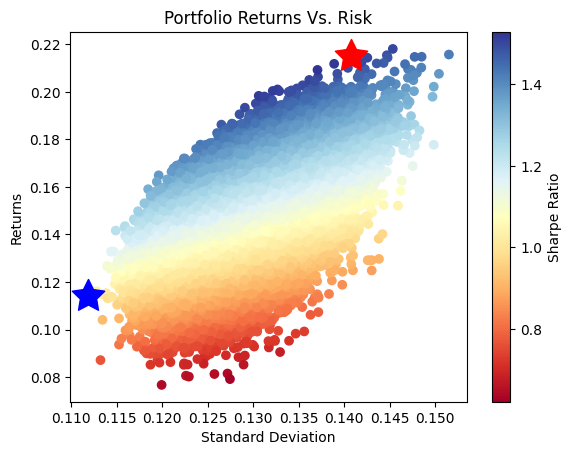

In [20]:
%matplotlib inline

# Plot the data on a Scatter plot.
plt.scatter(
    y=simulations_df['Returns'],
    x=simulations_df['Volatility'],
    c=simulations_df['Sharpe Ratio'],
    cmap='RdYlBu'
)

# Give the Plot some labels, and titles.
plt.title('Portfolio Returns Vs. Risk')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Standard Deviation')
plt.ylabel('Returns')

# Plot the Max Sharpe Ratio, using a `Red Star`.
plt.scatter(
    max_sharpe_ratio[1],
    max_sharpe_ratio[0],
    marker=(5, 1, 0),
    color='r',
    s=600
)

# Plot the Min Volatility, using a `Blue Star`.
plt.scatter(
    min_volatility[1],
    min_volatility[0],
    marker=(5, 1, 0),
    color='b',
    s=600
)

# Finally, show the plot.
plt.show()

##**Some Useful Functions**

In [21]:
def get_metrics(weights: list) -> np.array:
    """
    With a given set of weights, return the portfolio returns,
    the portfolio volatility, and the portfolio sharpe ratio.
    """

    # Converting to a Numpy Array.
    weights = np.array(weights)

    # Calculating the returns and annualize them
    ret = np.sum(log_return.mean() * weights) * 252

    # Calculate the volatility and annualize them
    vol = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                log_return.cov() * 252,
                weights
            )
        )
    )

    # Calculate the Sharpe Ratio.
    sr = ret / vol

    return np.array([ret, vol, sr])

def grab_negative_sharpe(weights: list) -> np.array:
    """The function used to maximise the Sharpe Ratio.
    """
    # To maximize Sharpe Ratio using a minimizer, return the negative Sharpe Ratio
    return -get_metrics(weights)[2]

def grab_volatility(weights: list) -> np.array:
    """The function used to minimize the Volatility.
    """
    return get_metrics(weights)[1]

def check_sum(weights: list) -> float:
    """Ensure the allocations of the weights, sums to 1
    """
    return np.sum(weights) - 1

##**Portfolio Optimization Technique -2 : Sequential Least Squares Programming**

Sequential Least Squares Programming (SLSQP) is a gradient-based optimization algorithm used to solve nonlinear optimization problems with constraints. It is widely used in portfolio optimization because it can handle equality constraints, inequality constraints, and variable bounds simultaneously.

At each iteration, SLSQP approximates the original nonlinear optimization problem with a simpler quadratic programming subproblem. It then solves this subproblem, updates the solution, and repeats the process until convergence. This iterative approach makes the algorithm efficient for many practical optimization problems.

In portfolio optimization, SLSQP is commonly used to maximize the Sharpe ratio or minimize portfolio risk while satisfying constraints such as:

- The sum of portfolio weights equals 1
- No short selling (weights ≥ 0).
- Maximum allocation limits for individual assets.

### **Advantages**
- Handles both equality and inequality constraints.
- Supports upper and lower bounds on variables.
- Efficient for small to medium-sized optimization problems.
- Widely available through SciPy's `minimize()` function.

### **Limitations**
- Requires the objective function to be smooth and differentiable.
- Finds a local optimum, which may not always be the global optimum.
- Performance can depend on the initial starting solution.

SLSQP is one of the most commonly used optimization algorithms in quantitative finance and is well suited for constructing optimal portfolios using the Markowitz Mean-Variance framework, Maximum Sharpe Ratio optimization, and Minimum Variance portfolio optimization.

In [22]:
# Define the boundaries for each symbol. Remember I can only invest up to 100% of my capital into a single asset.
bounds = tuple((0, 1) for symbol in range(number_of_symbols-1))

# Define the constraints, here I'm saying that the sum of each weight must not exceed 100%.
constraints = ({'type': 'eq', 'fun': check_sum})

# We need to create an initial guess to start with,
# and usually the best initial guess is just an
# even distribution.
init_guess = (number_of_symbols-1) * [1 / (number_of_symbols-1)]

# Perform the operation to minimize the risk.
optimized_sharpe = sci_opt.minimize(
    grab_negative_sharpe, # minimize this.
    init_guess, # Start with these values.
    method='SLSQP',
    bounds=bounds, # don't exceed these bounds.
    constraints=constraints # make sure you don't exceed the 100% constraint.
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED SHARPE RATIO:')
print('-'*80)
print(optimized_sharpe)
print('-'*80)   ##you can optimise for minimum volatility or for return also , -food for future work


OPTIMIZED SHARPE RATIO:
--------------------------------------------------------------------------------
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -1.7952805786365147
           x: [ 4.451e-17  2.130e-01 ...  1.362e-02  5.993e-17]
         nit: 10
         jac: [ 3.699e-01  5.991e-04 ... -4.577e-04  2.595e-01]
        nfev: 206
        njev: 10
 multipliers: [ 6.346e-05]
--------------------------------------------------------------------------------


In [23]:
# Getting the metrics
optimized_metrics = get_metrics(weights=optimized_sharpe.x)

# Getting the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_sharpe.x)
print('-'*80)


# Getting the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[4.45100125e-17 2.13042603e-01 2.62062498e-01 1.01551970e-02
 4.09680425e-17 0.00000000e+00 8.72312170e-02 4.90973030e-16
 4.68638037e-17 2.34018930e-02 1.23493330e-01 4.69549839e-02
 1.87168193e-16 6.43062113e-17 2.65941247e-17 2.20041178e-01
 4.11153529e-16 1.36170998e-02 5.99331052e-17]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[0.27177075 0.15138065 1.79528058]
--------------------------------------------------------------------------------


In [24]:
# Let us define the boundaries for each symbol.
bounds = tuple((0, 1) for symbol in range(number_of_symbols-1))

# We define  the constraints, by stating that the sum of all weights must not exceed 100%.
constraints = ({'type': 'eq', 'fun': check_sum})

# We need to create an initial guess to start with,
# and usually the best initial guess is just an
# even distribution. In this case 25% for each of the 4 stocks.
init_guess = (number_of_symbols-1) * [1 / (number_of_symbols-1)]

# Perform the operation to minimize the risk.
optimized_volatility = sci_opt.minimize(
    grab_volatility, # minimize this.
    init_guess, # Start with these values.
    method='SLSQP',
    bounds=bounds, # don't exceed these bounds.
    constraints=constraints # make sure you don't exceed the 100% constraint.
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED VOLATILITY RATIO:')
print('-'*80)
print(optimized_volatility)
print('-'*80)


OPTIMIZED VOLATILITY RATIO:
--------------------------------------------------------------------------------
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.10796816680934619
           x: [ 0.000e+00  0.000e+00 ...  1.900e-02  0.000e+00]
         nit: 8
         jac: [ 1.213e-01  1.166e-01 ...  1.074e-01  1.125e-01]
        nfev: 161
        njev: 8
 multipliers: [ 1.080e-01]
--------------------------------------------------------------------------------


In [25]:
# Grab the metrics.
optimized_metrics = get_metrics(weights=optimized_volatility.x)

# Print the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_volatility.x)
print('-'*80)


# Print the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[0.00000000e+00 0.00000000e+00 7.30569580e-02 1.20545293e-01
 7.71244106e-02 1.56391874e-01 1.11375872e-01 0.00000000e+00
 1.28385008e-01 0.00000000e+00 0.00000000e+00 4.61493949e-02
 2.04681187e-02 2.43574968e-02 2.85361692e-18 1.31288590e-01
 9.18522923e-02 1.90046920e-02 0.00000000e+00]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[0.10118012 0.10796817 0.93712916]
--------------------------------------------------------------------------------


##**Conclusion**

We started our journey by downloading data of some stocks from yfinance.Eventually , we ran some Monte Carlo simulations and performed an optimization technique(SLSQP) to get the 'best' possible allocation for our clients.The goodness of our allocation was judged using Sharpe Ratio.We also testes to minimize the volatility of our portfolio as a separate part of the project.

*   **Sharpe Ratio From Monte Carlo** -  1.52838


*   **Returns From Monte Carlo**   - 21.5124%                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

*   **Volatility From Monte Carlo** - 14.0753%


*   **Sharpe Ratio From SLSQP** - 1.79528


*   **Returns From SLSQP** - 27.17707%
*   **Volatility from SLSQP** -15.13806%


